### generate multilabel confusion matrix with data input from excel assessment of results
need to work on staying in python and not excel

In [1]:
pip install -U scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 20.5 MB/s  0:00:00m0:00:0100:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install -U seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [370]:
import numpy as np
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import cohen_kappa_score
import seaborn as sns
import pandas as pd



In [352]:
# ground truth
gt_train_rpts = pd.read_excel(io='/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/bondsAllocsJune7.xlsx', sheet_name='ground_truth_train', dtype={'pdfname': str, "gt_source": str, "ES_0_percent": bool, "ES_100_percent": bool, "ES_partial": bool, "number_of_cats": int})
gt_train_df = pd.DataFrame(gt_train_rpts)
gt_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   pdfname         34 non-null     str  
 1   gt_source       34 non-null     str  
 2   ES_0_percent    34 non-null     bool 
 3   ES_100_percent  34 non-null     bool 
 4   ES_partial      34 non-null     bool 
 5   number_of_cats  34 non-null     int64
dtypes: bool(3), int64(1), str(2)
memory usage: 2.4 KB


In [353]:
gt_train_df

,pdfname,gt_source,ES_0_percent,ES_100_percent,ES_partial,number_of_cats
0,Climate_Bond_Framework_of_E1_SUBHOLDING_S_A__i...,alloc data table,False,True,False,0
1,Bci_Sustainable_Financing_Framework,manual,False,False,True,6
2,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,False,False,True,5
3,BTG_Sustainable_Financing_Framework,manual,False,False,True,8
4,CABEI_Green_Bond_Framework,manual,False,False,True,4
5,CADU_GREEN_BOND_FRAMEWORK,manual,True,False,False,0
6,CAFs_GREEN_BOND_FRAMEWORK,manual,False,False,True,6
7,CIFI_Green_Bond_Framework,manual,False,False,True,3
8,EGE_Haina_Green_Securities_Framework,manual,False,True,False,0
9,FS_Green_Bond_Framework_-_July_2021,manual,False,False,True,2


In [354]:
# create y_true based on ES percent cols
ES_percent_true = []
for r in gt_train_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_true.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_true.append('ES 100%')
    elif r.ES_partial:
        ES_percent_true.append('ES partial')
gt_train_df['ES_percent_true'] = ES_percent_true

In [355]:
gt_train_df

,pdfname,gt_source,ES_0_percent,ES_100_percent,ES_partial,number_of_cats,ES_percent_true
0,Climate_Bond_Framework_of_E1_SUBHOLDING_S_A__i...,alloc data table,False,True,False,0,ES 100%
1,Bci_Sustainable_Financing_Framework,manual,False,False,True,6,ES partial
2,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,False,False,True,5,ES partial
3,BTG_Sustainable_Financing_Framework,manual,False,False,True,8,ES partial
4,CABEI_Green_Bond_Framework,manual,False,False,True,4,ES partial
5,CADU_GREEN_BOND_FRAMEWORK,manual,True,False,False,0,ES 0%
6,CAFs_GREEN_BOND_FRAMEWORK,manual,False,False,True,6,ES partial
7,CIFI_Green_Bond_Framework,manual,False,False,True,3,ES partial
8,EGE_Haina_Green_Securities_Framework,manual,False,True,False,0,ES 100%
9,FS_Green_Bond_Framework_-_July_2021,manual,False,False,True,2,ES partial


In [356]:
# pipeline predictions - V4 sim TH = 0.65
pred_train_rpts = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/pred_train_rpts_V4.csv')
pred_train_df = pd.DataFrame(pred_train_rpts)
pred_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pdfname               34 non-null     str    
 1   nlp_path              34 non-null     str    
 2   language              34 non-null     str    
 3   similarity_threshold  34 non-null     float64
 4   cleanup_threshold     34 non-null     float64
 5   ES_0_percent          34 non-null     bool   
 6   ES_100_percent        34 non-null     bool   
 7   ES_partial            34 non-null     bool   
 8   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(1), str(3)
memory usage: 3.5 KB


In [243]:
# pipeline predictions - V5 sim TH = 0.80
pred_train_rpts_v5 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/pred_train_rpts_V5.csv')
pred_train_df_v5 = pd.DataFrame(pred_train_rpts_v5)
pred_train_df_v5.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pdfname               34 non-null     str    
 1   nlp_path              34 non-null     str    
 2   language              34 non-null     str    
 3   similarity_threshold  34 non-null     float64
 4   cleanup_threshold     34 non-null     float64
 5   ES_0_percent          34 non-null     bool   
 6   ES_100_percent        34 non-null     bool   
 7   ES_partial            34 non-null     bool   
 8   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(1), str(3)
memory usage: 3.5 KB


In [245]:
# pipeline predictions - V6 sim TH = 0.88 & cleanup TH 0.70
pred_train_rpts_v6 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/pred_train_rpts_V6.csv')
pred_train_df_v6 = pd.DataFrame(pred_train_rpts_v6)
pred_train_df_v6.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pdfname               34 non-null     str    
 1   nlp_path              34 non-null     str    
 2   language              34 non-null     str    
 3   similarity_threshold  34 non-null     float64
 4   cleanup_threshold     34 non-null     float64
 5   ES_0_percent          34 non-null     bool   
 6   ES_100_percent        34 non-null     bool   
 7   ES_partial            34 non-null     bool   
 8   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(1), str(3)
memory usage: 3.5 KB


In [357]:
# pipeline predictions - V7 sim TH = 0.88 & cleanup TH 0.70
pred_train_rpts_v7 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/pred_train_rpts_V7.csv')
pred_train_df_v7 = pd.DataFrame(pred_train_rpts_v7)
pred_train_df_v7.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            34 non-null     int64  
 1   pdfname               34 non-null     str    
 2   nlp_path              34 non-null     str    
 3   language              34 non-null     str    
 4   similarity_threshold  34 non-null     float64
 5   cleanup_threshold     34 non-null     float64
 6   ES_0_percent          34 non-null     bool   
 7   ES_100_percent        34 non-null     bool   
 8   ES_partial            34 non-null     bool   
 9   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(2), str(3)
memory usage: 3.7 KB


In [246]:
# create y_pred based on ES percent cols - V4 sim TH = 0.65
ES_percent_pred = []
for r in pred_train_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df['ES_percent_pred'] = ES_percent_pred


In [247]:
# create y_pred based on ES percent cols - V5 sim TH = 0.80
ES_percent_pred = []
for r in pred_train_df_v5.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df_v5['ES_percent_pred'] = ES_percent_pred

In [248]:
# create y_pred based on ES percent cols - V6 sim TH = 0.88 & cleanup TH 0.70
ES_percent_pred = []
for r in pred_train_df_v6.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df_v6['ES_percent_pred'] = ES_percent_pred

In [358]:
# create y_pred based on ES percent cols - V7 sim TH = 0.88 & cleanup TH 0.70
ES_percent_pred = []
for r in pred_train_df_v7.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df_v7['ES_percent_pred'] = ES_percent_pred

In [271]:
# create a dataset containing results for confusion matrix - V4 sim TH = 0.65

conf_mtrx_df = pd.DataFrame()

conf_mtrx_df['pdfname'] = pred_train_df['pdfname']
conf_mtrx_df['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df['nlp_path'] = pred_train_df['nlp_path']
conf_mtrx_df['language'] = pred_train_df['language']
conf_mtrx_df['similarity_th'] = pred_train_df['similarity_threshold']
conf_mtrx_df['cleanup_th'] = pred_train_df['cleanup_threshold']
conf_mtrx_df['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df['ES_percent_pred'] = pred_train_df['ES_percent_pred']
conf_mtrx_df['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df['num_cats_pred'] = pred_train_df['number_of_cats']
conf_mtrx_df['num_cats_diff'] = conf_mtrx_df['num_cats_true'] - conf_mtrx_df['num_cats_pred']


In [272]:
# create a dataset containing results for confusion matrix - V5 sim TH = 0.80

conf_mtrx_df_v5 = pd.DataFrame()

conf_mtrx_df_v5['pdfname'] = pred_train_df_v5['pdfname']
conf_mtrx_df_v5['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df_v5['nlp_path'] = pred_train_df_v5['nlp_path']
conf_mtrx_df_v5['language'] = pred_train_df_v5['language']
conf_mtrx_df_v5['similarity_th'] = pred_train_df_v5['similarity_threshold']
conf_mtrx_df_v5['cleanup_th'] = pred_train_df_v5['cleanup_threshold']
conf_mtrx_df_v5['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df_v5['ES_percent_pred'] = pred_train_df_v5['ES_percent_pred']
conf_mtrx_df_v5['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df_v5['num_cats_pred'] = pred_train_df_v5['number_of_cats']
conf_mtrx_df_v5['num_cats_diff'] = conf_mtrx_df_v5['num_cats_true'] - conf_mtrx_df_v5['num_cats_pred']

In [273]:
# create a dataset containing results for confusion matrix - V6 sim TH = 0.88 & cleanup TH 0.70

conf_mtrx_df_v6 = pd.DataFrame()

conf_mtrx_df_v6['pdfname'] = pred_train_df_v6['pdfname']
conf_mtrx_df_v6['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df_v6['nlp_path'] = pred_train_df_v6['nlp_path']
conf_mtrx_df_v6['language'] = pred_train_df_v6['language']
conf_mtrx_df_v6['similarity_th'] = pred_train_df_v6['similarity_threshold']
conf_mtrx_df_v6['cleanup_th'] = pred_train_df_v6['cleanup_threshold']
conf_mtrx_df_v6['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df_v6['ES_percent_pred'] = pred_train_df_v6['ES_percent_pred']
conf_mtrx_df_v6['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df_v6['num_cats_pred'] = pred_train_df_v6['number_of_cats']
conf_mtrx_df_v6['num_cats_diff'] = conf_mtrx_df_v6['num_cats_true'] - conf_mtrx_df_v6['num_cats_pred']

In [359]:
# create a dataset containing results for confusion matrix - V7 sim TH = 0.88 & cleanup TH 0.70

conf_mtrx_df_v7 = pd.DataFrame()

conf_mtrx_df_v7['pdfname'] = pred_train_df_v7['pdfname']
conf_mtrx_df_v7['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df_v7['nlp_path'] = pred_train_df_v7['nlp_path']
conf_mtrx_df_v7['language'] = pred_train_df_v7['language']
conf_mtrx_df_v7['similarity_th'] = pred_train_df_v7['similarity_threshold']
conf_mtrx_df_v7['cleanup_th'] = pred_train_df_v7['cleanup_threshold']
conf_mtrx_df_v7['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df_v7['ES_percent_pred'] = pred_train_df_v7['ES_percent_pred']
conf_mtrx_df_v7['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df_v7['num_cats_pred'] = pred_train_df_v7['number_of_cats']
conf_mtrx_df_v7['num_cats_diff'] = conf_mtrx_df_v7['num_cats_true'] - conf_mtrx_df_v7['num_cats_pred']

In [275]:
# create ES Partial TP col based on ES percent cols - V4 sim TH = 0.65
ES_partial_True_Positives = []
for r in conf_mtrx_df.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df['ES_partial_True_Positives'].value_counts()
conf_mtrx_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    34 non-null     str    
 1   gt_source                  34 non-null     str    
 2   nlp_path                   34 non-null     str    
 3   language                   34 non-null     str    
 4   similarity_th              34 non-null     float64
 5   cleanup_th                 34 non-null     float64
 6   ES_percent_true            34 non-null     str    
 7   ES_percent_pred            34 non-null     str    
 8   num_cats_true              34 non-null     int64  
 9   num_cats_pred              34 non-null     int64  
 10  num_cats_diff              34 non-null     int64  
 11  ES_partial_True_Positives  34 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 5.5 KB


In [276]:
# create ES Partial TP col based on ES percent cols - V5 sim TH = 0.80
ES_partial_True_Positives = []
for r in conf_mtrx_df_v5.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df_v5['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df_v5['ES_partial_True_Positives'].value_counts()
conf_mtrx_df_v5.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    34 non-null     str    
 1   gt_source                  34 non-null     str    
 2   nlp_path                   34 non-null     str    
 3   language                   34 non-null     str    
 4   similarity_th              34 non-null     float64
 5   cleanup_th                 34 non-null     float64
 6   ES_percent_true            34 non-null     str    
 7   ES_percent_pred            34 non-null     str    
 8   num_cats_true              34 non-null     int64  
 9   num_cats_pred              34 non-null     int64  
 10  num_cats_diff              34 non-null     int64  
 11  ES_partial_True_Positives  34 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 5.5 KB


In [335]:
# create ES Partial TP col based on ES percent cols - V6 sim TH = 0.88 & cleanup TH 0.70
ES_partial_True_Positives = []
for r in conf_mtrx_df_v6.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df_v6['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df_v6['ES_partial_True_Positives'].value_counts()


ES_partial_True_Positives
False    18
True     16
Name: count, dtype: int64

In [360]:
# create ES Partial TP col based on ES percent cols - V7 sim TH = 0.88 & cleanup TH 0.70
ES_partial_True_Positives = []
for r in conf_mtrx_df_v7.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df_v7['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df_v7['ES_partial_True_Positives'].value_counts()

ES_partial_True_Positives
False    17
True     17
Name: count, dtype: int64

In [279]:
# bring in data from eval - V4 sim TH = 0.65

y_true = conf_mtrx_df['ES_percent_true']
y_pred = conf_mtrx_df['ES_percent_pred']
labels = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true, y_pred, labels=labels)

array([[[29,  1],
        [ 3,  1]],

       [[22,  1],
        [ 8,  3]],

       [[ 4, 11],
        [ 2, 17]]])

In [280]:
# bring in data from eval - V5 sim TH = 0.80

y_true_v5 = conf_mtrx_df_v5['ES_percent_true']
y_pred_v5 = conf_mtrx_df_v5['ES_percent_pred']
labels_v5 = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true_v5, y_pred_v5, labels=labels_v5)

array([[[28,  2],
        [ 1,  3]],

       [[23,  0],
        [ 7,  4]],

       [[ 7,  8],
        [ 2, 17]]])

In [281]:
# bring in data from eval - V6 sim TH = 0.88 & cleanup TH 0.70

y_true_v6 = conf_mtrx_df_v6['ES_percent_true']
y_pred_v6 = conf_mtrx_df_v6['ES_percent_pred']
labels_v6 = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true_v6, y_pred_v6, labels=labels_v6)

array([[[27,  3],
        [ 1,  3]],

       [[23,  0],
        [ 6,  5]],

       [[ 8,  7],
        [ 3, 16]]])

In [361]:
# bring in data from eval - V7 sim TH = 0.88 & cleanup TH 0.70

y_true_v7 = conf_mtrx_df_v7['ES_percent_true']
y_pred_v7 = conf_mtrx_df_v7['ES_percent_pred']
labels_v7 = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true_v7, y_pred_v7, labels=labels_v7)

array([[[28,  3],
        [ 0,  3]],

       [[23,  0],
        [ 6,  5]],

       [[ 8,  6],
        [ 3, 17]]])

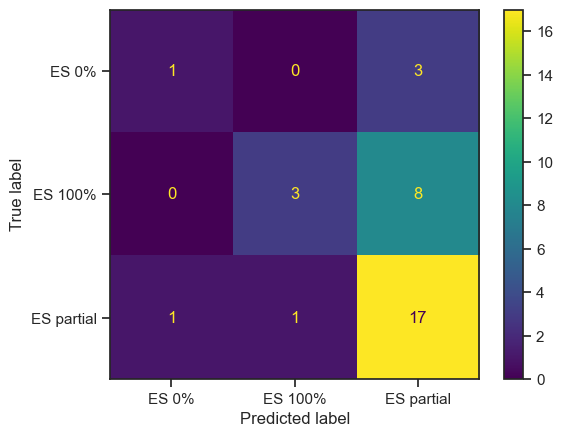

In [282]:
# display confusion matrix - V4 sim TH = 0.65

cm = multilabel_confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

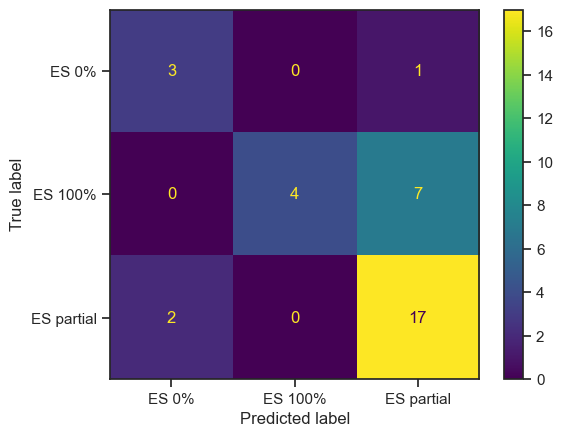

In [283]:
# display confusion matrix - V5 sim TH = 0.80

cm = multilabel_confusion_matrix(y_true_v5, y_pred_v5)
disp = ConfusionMatrixDisplay.from_predictions(y_true_v5, y_pred_v5)
plt.show()


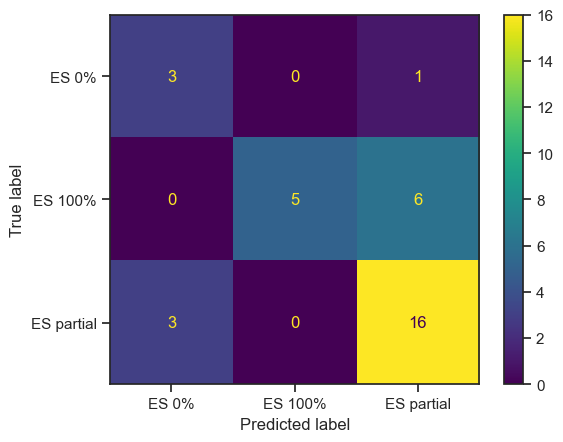

In [284]:
# display confusion matrix - V6 sim TH = 0.88 & cleanup TH 0.70

cm = multilabel_confusion_matrix(y_true_v6, y_pred_v6)
disp = ConfusionMatrixDisplay.from_predictions(y_true_v6, y_pred_v6)
plt.show()

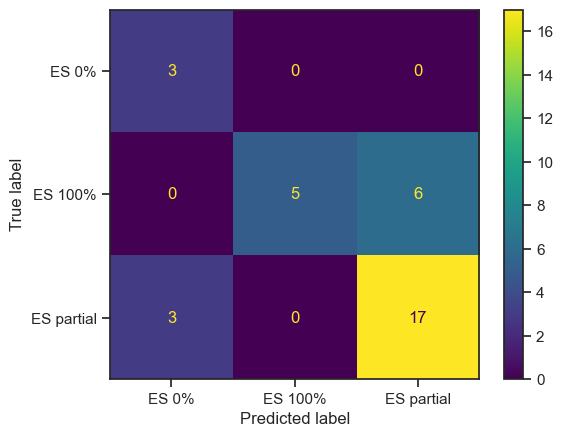

In [362]:
# display confusion matrix - V7 sim TH = 0.88 & cleanup TH 0.70

cm = multilabel_confusion_matrix(y_true_v7, y_pred_v7)
disp = ConfusionMatrixDisplay.from_predictions(y_true_v7, y_pred_v7)
plt.show()

In [363]:
# breakdown of ES 100% false negatives
# EGE a very good example of limitations of program
# Coop - problem with period in the ESML list. also problem with la and y in green buildings - limitation of program separates la from noun 
# inspect all 10 and cateogorise into limitations of prog and what that is vs fixable
# 10 falses - diagnose and would sim th by cat make any diff
trues = conf_mtrx_df_v7['ES_percent_true'] == 'ES 100%'
preds = conf_mtrx_df_v7['ES_percent_pred'] == 'ES partial'

ES_100_FNs = conf_mtrx_df_v7[trues & preds]
ES_100_FNs



,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
8,EGE_Haina_Green_Securities_Framework,manual,UOP_section_true,EN,0.88,0.7,ES 100%,ES partial,0,4,-4,False
11,Genneia_Green_Bond_Framework,manual,UOP_section_true,EN,0.88,0.7,ES 100%,ES partial,0,2,-2,False
16,ILAP_Green_Financing_Framework,manual,UOP_section_false,EN,0.88,0.7,ES 100%,ES partial,0,3,-3,False
27,Marco_de_Gestión_de_Bono_Verde,manual,UOP_section_false,ES,0.88,0.7,ES 100%,ES partial,0,2,-2,False
28,Marco_de_referencia_de_bono_verde_Coopeguanaca...,manual,UOP_section_true,ES,0.88,0.7,ES 100%,ES partial,0,3,-3,False
30,Nacional_Financiera_Green_Bond_MXN,manual,Table,ES,0.88,0.7,ES 100%,ES partial,0,2,-2,False


In [364]:
# breakdown of ES partials FNs
trues = conf_mtrx_df_v7['ES_percent_true'] == 'ES partial'
preds = conf_mtrx_df_v7['ES_percent_pred'] == 'ES 0%'

ES_partial_FNs = conf_mtrx_df_v7[trues & preds]
ES_partial_FNs

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
6,CAFs_GREEN_BOND_FRAMEWORK,manual,Table,EN,0.88,0.7,ES partial,ES 0%,6,3,3,False
15,Green_social_bond_framework_series_ad_ae_2019,alloc data table,Table,EN,0.88,0.7,ES partial,ES 0%,2,2,0,False
31,Marco_de_Uso_de_Fondo_para_la_Emision_de_Bonos...,manual,Table,ES,0.88,0.7,ES partial,ES 0%,8,1,7,False


In [365]:
# breakdown of ES 0% FNs
trues = conf_mtrx_df_v7['ES_percent_true'] == 'ES 0%'
preds = conf_mtrx_df_v7['ES_percent_pred'] == 'ES partial'

ES_0_FNs = conf_mtrx_df_v7[trues & preds]
ES_0_FNs

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives


In [367]:
# inspect table sims dicts
table_csv_v7 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/table_csv_v7.csv')
table_csv_v7 = pd.DataFrame(table_csv_v7)
table_csv_v7

,Unnamed: 0,pdfname,tablePages_list,table.Headers_list,countCat_words,unique compliant Categories_list,energy_system_tbl,table_idx_list,unique Cats all,simScores_cln,resimScores
0,0,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...","[15, 16, 17, 19]","[['Green\nProject\nCategory', 'Use of\nProceed...",5,"['clean transportation', 'sustainable water an...",True,"[0, 1, 1, 1, 1, 2, 2, 3, 3, 3, 3, 3, 3, 3]","['clean transportation', 'sustainable water an...",{'clean transportation transportation': 0.8166...,{'renewable': 1.0}
1,1,CABEI_Green_Bond_Framework,"[7, 8, 9, 10, 12]","[['Eligible\nGreen\nProjects\nCategories', 'Su...",3,"['renewable energy', 'sustainable land use', '...",True,"[0, 4, 4, 4, 4]","['clean transport', 'renewable energy', 'susta...",{'renewable energy renewable': 0.9201155304908...,{'renewable': 1.0}
2,2,CAFs_GREEN_BOND_FRAMEWORK,"[1, 2, 8, 9]","[['Measure of Units', 'Col1'], ['Graphics', 'C...",3,"['clean transportation', 'renewable energy', '...",True,"[2, 2, 2, 2]","['clean transportation', 'renewable energy', '...",{'clean transportation transportation': 0.8166...,{'renewable': 1.0}
3,3,Green_Bond_Financing_Framework,"[7, 8, 10]",[['Eligible Category aligned\nwith ICMA Green ...,2,"['clean transportation', 'energy efficiency']",False,"[0, 2, 2]","['clean transportation', 'energy efficiency']",{'clean transportation transportation': 0.8166...,{}
4,4,Green_Bond_Framework_of_Banco_Guayaquil,"[6, 7, 8, 9, 10, 18, 19, 29, 30, 31, 38, 39]","[['GBP Eligible\nGreen Assets\nCategory', 'Ban...",2,"['energy efficiency', 'renewable energy']",True,"[0, 1, 1, 1, 1]","['energy efficiency', 'renewable energy']",{'energy efficiency efficiency': 0.90048879384...,{'renewable': 1.0}
5,5,Green_Finance_Framework_Interchile,[8],"[['Eligible Project Category', 'Questions', 'A...",3,"['energy efficiency', 'renewable energy', 'cli...",True,"[0, 0, 0]","['renewable energy', 'energy efficiency', 'cli...",{'renewable energy renewable': 0.9201155304908...,{'renewable': 1.0}
6,6,Green_social_bond_framework_series_ad_ae_2019,"[3, 6, 7]","[['Category', 'Project name', 'Goal'], ['Categ...",2,"['potable water supply', 'sanitation']",False,"[0, 0, 0, 1, 1, 1]","['potable water supply', 'sanitation', 'resili...",{'potable water supply water': 0.8469440937042...,{}
7,7,ISA_CTM_FRAMEWORK,"[4, 5, 7, 8, 9, 15, 16, 17, 18]","[['Eligible Project Category', 'Questions', 'A...",2,"['energy efficiency', 'renewable energy']",True,"[0, 0]","['energy efficiency', 'renewable energy']",{'energy efficiency efficiency': 0.90048879384...,{'renewable': 1.0}
8,8,Sicredi_Green_Bond_Framework,"[4, 6]","[['Eligible\nCategories', 'Description', 'Obje...",2,"['energy efficiency', 'renewable energy']",True,"[0, 0]","['energy efficiency', 'renewable energy']",{'energy efficiency efficiency': 0.90048879384...,{'renewable': 1.0}
9,9,Chile_Sustainable_Bond_Framework,"[0, 19, 20, 21, 22, 23, 24, 25, 26, 30, 37, 38...","[['Col0', 'Ministry of\nFinance\nGovernment of...",6,"['energy efficiency', 'renewable energy', 'acc...",True,"[5, 5, 5, 5, 6, 6, 7, 7, 7, 8, 8, 10, 10, 10, ...",['support for the community through job creati...,{'energy efficiency efficiency': 0.90048879384...,{'renewable': 1.0}


In [349]:
table_csv_v7.iloc[11].loc['unique Cats all']

"['proyecto de energías renovables (energía hidroeléctrica – contribución a mitigación del cambio climático)']"

In [368]:
# inspect UOP sims dicts
UOP_Words_csv_v7 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/UOP_Words_csv_v7.csv')
UOP_Words_csv_v7 = pd.DataFrame(UOP_Words_csv_v7)
UOP_Words_csv_v7

,Unnamed: 0,pdfname,energy_system_uop,simsre,simsee,simsppc,simsesml,simstabc,simsct,simsswwm,simscca,simsce,simsgb
0,0,Climate_Bond_Framework_of_E1_SUBHOLDING_S_A__i...,True,"{'generation generation': 1.0, 'power power': ...",{},{},{},{},{},{},{},{},{}
1,1,Bci_Sustainable_Financing_Framework,True,"{'generation generation': 1.0, 'power power': ...",{'efficiency efficiency': 1.0},{'waste waste': 1.0},{},{},"{'electric electric': 1.0, 'car car': 1.0, 'tr...","{'water water': 1.0, 'potable potable': 1.0, '...",{},{},{'buildings buildings': 1.0}
2,2,BTG_Sustainable_Financing_Framework,True,"{'grid grid': 1.0, 'storage storage': 1.0, 're...",{'efficiency efficiency': 1.0},"{'pollution pollution': 1.0, 'waste waste': 1.0}","{'food food': 1.0, 'agriculture agriculture': ...","{'biodiversity biodiversity': 1.0, 'conservati...","{'electric electric': 1.0, 'rail rail': 1.0, '...","{'wastewater wastewater': 1.0, 'water water': ...",{'adaptation adaptation': 1.0},{},"{'buildings buildings': 1.0, 'housing housing'..."
3,3,CADU_GREEN_BOND_FRAMEWORK,False,{},{'efficiency efficiency': 1.0},{'waste waste': 1.0},{},{},{},{'water water': 1.0},{},{},"{'buildings buildings': 1.0, 'housing housing'..."
4,4,CIFI_Green_Bond_Framework,True,"{'power power': 1.0, 'renewable renewable': 1....",{},{'waste waste': 1.0},{},{},{},"{'treatment treatment': 1.0, 'wastewater waste...",{},{},{}
5,5,EGE_Haina_Green_Securities_Framework,True,"{'generation generation': 1.0, 'power power': ...",{},{},{'land land': 1.0},{},{'electric electric': 1.0},{'water water': 1.0},{},{},{}
6,6,FS_Green_Bond_Framework_-_July_2021,True,"{'generation generation': 1.0, 'storage storag...",{},{},"{'forest forests': 0.8802252411842346, 'agricu...",{},{'car car': 1.0},{'water water': 1.0},{},{},{}
7,7,FS_Green_Bond_Framework_-_November_2020,True,"{'generation generation': 1.0, 'storage storag...",{},{},"{'forest forests': 0.8802252411842346, 'agricu...",{},{'car car': 1.0},{'water water': 1.0},{},{},{}
8,8,Genneia_Green_Bond_Framework,True,"{'renewable renewable': 1.0, 'wind wind': 1.0,...",{},{},{},{},{'battery battery': 1.0},{},{},{},{}
9,9,ILAP_Green_Financing_Framework,True,"{'generation generation': 1.0, 'power power': ...",{},{'pollution pollution': 1.0},{},{'biodiversity biodiversity': 1.0},{},{},{},{},{}


In [ ]:
UOP_Words_csv_v7.iloc[19].loc['simsppc']

"{'de de': 0.9079835414886475}"

#### root cause and fixes
27	Marco_de_Gestión_de_Bono_Verde - found algorithmic errors in use of cats from table attributes - these have been corrected
31	Marco_de_Uso_de_Fondo_para_la_Emision_de_Bonos...	ground truth corrected - report covers two tranches, corrected to 1 tranche and green only (consistent with other corrections). probably due to table being over several pages not being handled accurately by the code - need to prove and see if a fix is possible
28	Marco_de_referencia_de_bono_verde_Coopeguanaca... even if fix from v5 is corrected (de and la assessment) still show up as partial de to limitation similar to EGE
8	EGE_Haina_Green_Securities_Framework - good example of limitations of prog
21	SONDA_S_A__GREEN_BOND_FRAMEWORK - alloc table data replaced with manual - overall gb but inclues re & ee. still has prog lim
15	Green_social_bond_framework_series_ad_ae_2019 prog lim in taking only LHCol of table
6	CAFs_GREEN_BOND_FRAMEWORK limitation of table going over page leading to missing rows but the ES 0% pred doesn't make sense - maybe this changes when we re-run
16	ILAP_Green_Financing_Framework - words from non UOP section
30	Nacional_Financiera_Green_Bond_MXN - limitation of prog - LHCol more granular
11	Genneia_Green_Bond_Framework - consider removing battery from CT list





In [390]:
# accuracy metrix - V4 sim TH = 0.65

as_frac = round(accuracy_score(y_true, y_pred),2)
accuracy_score_num = accuracy_score(y_true, y_pred, normalize=False)
print(as_frac, accuracy_score_num)

ck = round(cohen_kappa_score(y_true, y_pred),2)
print(ck)

f1 = round(f1_score(y_true, y_pred, average='macro'),2)
print(f1)

0.62 21.0
0.23
0.49


In [389]:
# accuracy metrix - V5 sim TH = 0.80

as_frac_v5 = round(accuracy_score(y_true_v5, y_pred_v5),2)
accuracy_score_num_v5 = accuracy_score(y_true_v5, y_pred_v5, normalize=False)
print(as_frac_v5, accuracy_score_num_v5)

ck_v5 = round(cohen_kappa_score(y_true_v5, y_pred_v5),2)
print(ck_v5)

f1_v5 = round(f1_score(y_true_v5, y_pred_v5, average='macro'),2)
print(f1_v5)

0.71 24.0
0.45
0.66


In [388]:
# accuracy metrix - V6 sim TH = 0.88 & cleanup TH 0.70

as_frac_v6 = round(accuracy_score(y_true_v6, y_pred_v6),2)
accuracy_score_num_v6 = accuracy_score(y_true_v6, y_pred_v6, normalize=False)
print(as_frac_v6, accuracy_score_num_v6)

ck_v6 = round(cohen_kappa_score(y_true_v6, y_pred_v6),2)
print(ck_v6)

f1_v6 = round(f1_score(y_true_v6, y_pred_v6, average='macro'),2)
print(f1_v6)

0.71 24.0
0.47
0.66


In [387]:
# accuracy metrix - V7 sim TH = 0.88 & cleanup TH 0.70

as_frac_v7 = round(accuracy_score(y_true_v7, y_pred_v7),2)
accuracy_score_num_v7 = accuracy_score(y_true_v7, y_pred_v7, normalize=False)
print(as_frac_v7, accuracy_score_num_v7)

ck_v7 = round(cohen_kappa_score(y_true_v7, y_pred_v7),2)
print(ck_v7)

f1_v7 = round(f1_score(y_true_v7, y_pred_v7, average='macro'),2)
print(f1_v7)

0.74 25.0
0.51
0.69


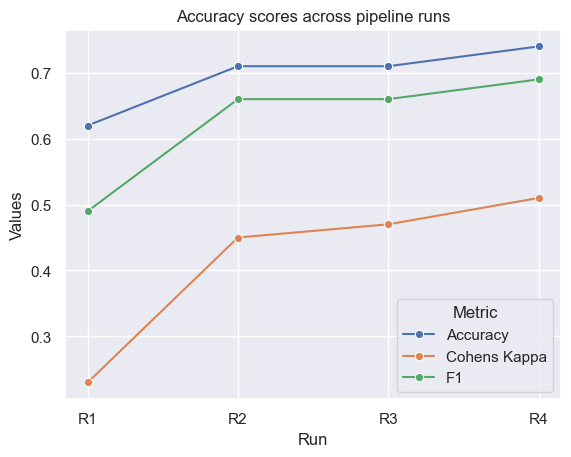

In [393]:
# line plot the accuracy results

accuracy_measures = {'Run': ['R1', 'R1','R1', 'R2', 'R2', 'R2',
                             'R3', 'R3', 'R3', 'R4', 'R4', 'R4'],
                    'Metric': ['Accuracy', 'Cohens Kappa' , 'F1' , 'Accuracy', 'Cohens Kappa' , 'F1',
                               'Accuracy', 'Cohens Kappa' , 'F1' , 'Accuracy', 'Cohens Kappa' , 'F1'],
                    'Values': [as_frac, ck, f1, as_frac_v5, ck_v5, f1_v5, 
                               as_frac_v6, ck_v6, f1_v6, as_frac_v7, ck_v7, f1_v7]}
acc_meas_df = pd.DataFrame(accuracy_measures)
sns.set_theme(style = "darkgrid")
sns.lineplot(data = acc_meas_df, x = 'Run', y = 'Values', hue= 'Metric', marker = 'o')

plt.title('Accuracy scores across pipeline runs')
plt.show()


In [288]:
# create a dataset containing results for boxplots - V4 sim TH = 0.65

boxplot_df = conf_mtrx_df.query("ES_partial_True_Positives == True")
boxplot_df.info()


<class 'pandas.DataFrame'>
Index: 17 entries, 1 to 29
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    17 non-null     str    
 1   gt_source                  17 non-null     str    
 2   nlp_path                   17 non-null     str    
 3   language                   17 non-null     str    
 4   similarity_th              17 non-null     float64
 5   cleanup_th                 17 non-null     float64
 6   ES_percent_true            17 non-null     str    
 7   ES_percent_pred            17 non-null     str    
 8   num_cats_true              17 non-null     int64  
 9   num_cats_pred              17 non-null     int64  
 10  num_cats_diff              17 non-null     int64  
 11  ES_partial_True_Positives  17 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.9 KB


In [289]:
# create a dataset containing results for boxplots - V5 sim TH = 0.80

boxplot_df_v5 = conf_mtrx_df_v5.query("ES_partial_True_Positives == True")
boxplot_df_v5.info()

<class 'pandas.DataFrame'>
Index: 17 entries, 1 to 29
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    17 non-null     str    
 1   gt_source                  17 non-null     str    
 2   nlp_path                   17 non-null     str    
 3   language                   17 non-null     str    
 4   similarity_th              17 non-null     float64
 5   cleanup_th                 17 non-null     float64
 6   ES_percent_true            17 non-null     str    
 7   ES_percent_pred            17 non-null     str    
 8   num_cats_true              17 non-null     int64  
 9   num_cats_pred              17 non-null     int64  
 10  num_cats_diff              17 non-null     int64  
 11  ES_partial_True_Positives  17 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.9 KB


In [290]:
# create a dataset containing results for boxplots - V6 sim TH = 0.88 & cleanup TH 0.70

boxplot_df_v6 = conf_mtrx_df_v6.query("ES_partial_True_Positives == True")
boxplot_df_v6.info()

<class 'pandas.DataFrame'>
Index: 16 entries, 1 to 29
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    16 non-null     str    
 1   gt_source                  16 non-null     str    
 2   nlp_path                   16 non-null     str    
 3   language                   16 non-null     str    
 4   similarity_th              16 non-null     float64
 5   cleanup_th                 16 non-null     float64
 6   ES_percent_true            16 non-null     str    
 7   ES_percent_pred            16 non-null     str    
 8   num_cats_true              16 non-null     int64  
 9   num_cats_pred              16 non-null     int64  
 10  num_cats_diff              16 non-null     int64  
 11  ES_partial_True_Positives  16 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.7 KB


In [339]:
# create a dataset containing results for boxplots - V7 sim TH = 0.88 & cleanup TH 0.70

boxplot_df_v7 = conf_mtrx_df_v7.query("ES_partial_True_Positives == True")
boxplot_df_v7.info()

<class 'pandas.DataFrame'>
Index: 17 entries, 1 to 29
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    17 non-null     str    
 1   gt_source                  17 non-null     str    
 2   nlp_path                   17 non-null     str    
 3   language                   17 non-null     str    
 4   similarity_th              17 non-null     float64
 5   cleanup_th                 17 non-null     float64
 6   ES_percent_true            17 non-null     str    
 7   ES_percent_pred            17 non-null     str    
 8   num_cats_true              17 non-null     int64  
 9   num_cats_pred              17 non-null     int64  
 10  num_cats_diff              17 non-null     int64  
 11  ES_partial_True_Positives  17 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.9 KB


<Axes: xlabel='num_cats_diff'>

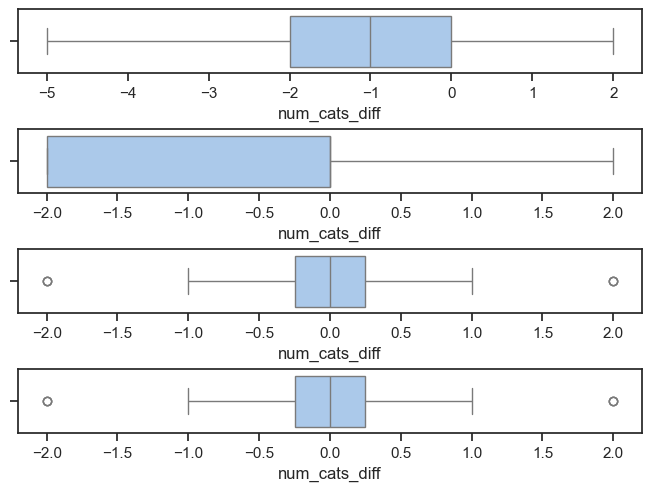

In [340]:
# boxplots of diff in number of cats - V4 sim TH = 0.65, V5 sim = 0.80 and V6 sim TH = 0.88 & cleanup TH 0.70

fig, axes = plt.subplots(4,1, layout = 'constrained')
sns.set_theme(style='ticks', palette = 'pastel')
sns.boxplot(x=boxplot_df['num_cats_diff'], ax=axes[0])
sns.boxplot(x=boxplot_df_v5['num_cats_diff'], ax=axes[1])
sns.boxplot(x=boxplot_df_v6['num_cats_diff'], ax=axes[2])
sns.boxplot(x=boxplot_df_v6['num_cats_diff'], ax=axes[3])


<Axes: xlabel='num_cats_diff', ylabel='language'>

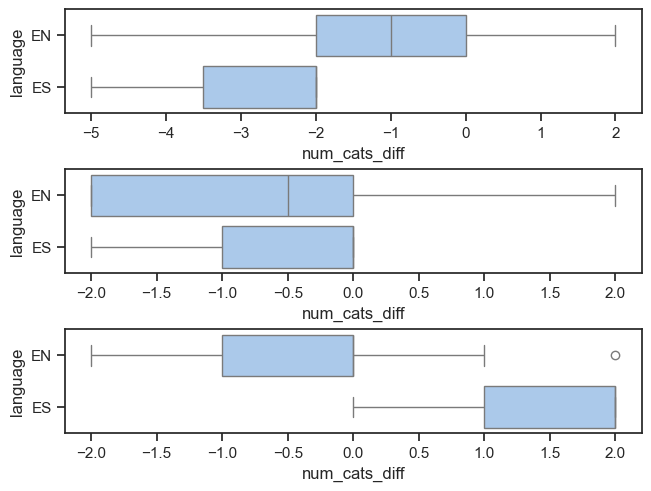

In [292]:
# boxplots of diff in number of cats - V4 sim TH = 0.65, V5 sim = 0.80 and V6 sim TH = 0.88 & cleanup TH 0.70

fig, axes = plt.subplots(3,1, layout = 'constrained')
sns.set_theme(style='ticks', palette = 'pastel')
sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['language'], ax=axes[0])
sns.boxplot(x=boxplot_df_v5['num_cats_diff'], y = boxplot_df_v5['language'], ax=axes[1])
sns.boxplot(x=boxplot_df_v6['num_cats_diff'], y = boxplot_df_v6['language'], ax=axes[2])


<Axes: xlabel='num_cats_diff', ylabel='nlp_path'>

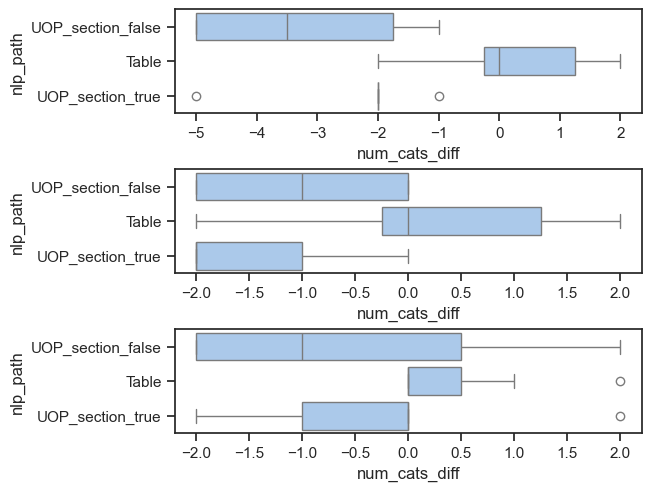

In [293]:
# boxplots of diff in number of cats - V4 sim TH = 0.65, V5 sim = 0.80 and V6 sim TH = 0.88 & cleanup TH 0.70

fig, axes = plt.subplots(3,1, layout = 'constrained')
sns.set_theme(style='ticks', palette = 'pastel')
sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['nlp_path'], ax=axes[0])
sns.boxplot(x=boxplot_df_v5['num_cats_diff'], y = boxplot_df_v5['nlp_path'], ax=axes[1])
sns.boxplot(x=boxplot_df_v6['num_cats_diff'], y = boxplot_df_v6['nlp_path'], ax=axes[2])

In [294]:
boxplot_df

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
1,Bci_Sustainable_Financing_Framework,manual,UOP_section_false,EN,0.65,0.65,ES partial,ES partial,6,7,-1,True
2,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,Table,EN,0.65,0.65,ES partial,ES partial,5,6,-1,True
3,BTG_Sustainable_Financing_Framework,manual,UOP_section_true,EN,0.65,0.65,ES partial,ES partial,8,10,-2,True
4,CABEI_Green_Bond_Framework,manual,Table,EN,0.65,0.65,ES partial,ES partial,4,3,1,True
6,CAFs_GREEN_BOND_FRAMEWORK,manual,Table,EN,0.65,0.65,ES partial,ES partial,6,4,2,True
7,CIFI_Green_Bond_Framework,manual,UOP_section_true,EN,0.65,0.65,ES partial,ES partial,3,4,-1,True
9,FS_Green_Bond_Framework_-_July_2021,manual,UOP_section_false,EN,0.65,0.65,ES partial,ES partial,2,7,-5,True
10,FS_Green_Bond_Framework_-_November_2020,manual,UOP_section_false,EN,0.65,0.65,ES partial,ES partial,2,7,-5,True
13,Green_Bond_Framework_of_Banco_Guayaquil,manual,Table,EN,0.65,0.65,ES partial,ES partial,4,2,2,True
14,Green_Finance_Framework_Interchile,manual,Table,EN,0.65,0.65,ES partial,ES partial,3,3,0,True


In [295]:
boxplot_df_v5

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
1,Bci_Sustainable_Financing_Framework,manual,UOP_section_false,EN,0.8,0.65,ES partial,ES partial,6,6,0,True
2,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,Table,EN,0.8,0.65,ES partial,ES partial,5,6,-1,True
3,BTG_Sustainable_Financing_Framework,manual,UOP_section_true,EN,0.8,0.65,ES partial,ES partial,8,10,-2,True
4,CABEI_Green_Bond_Framework,manual,Table,EN,0.8,0.65,ES partial,ES partial,4,3,1,True
6,CAFs_GREEN_BOND_FRAMEWORK,manual,Table,EN,0.8,0.65,ES partial,ES partial,6,4,2,True
7,CIFI_Green_Bond_Framework,manual,UOP_section_true,EN,0.8,0.65,ES partial,ES partial,3,4,-1,True
9,FS_Green_Bond_Framework_-_July_2021,manual,UOP_section_false,EN,0.8,0.65,ES partial,ES partial,2,4,-2,True
10,FS_Green_Bond_Framework_-_November_2020,manual,UOP_section_false,EN,0.8,0.65,ES partial,ES partial,2,4,-2,True
13,Green_Bond_Framework_of_Banco_Guayaquil,manual,Table,EN,0.8,0.65,ES partial,ES partial,4,2,2,True
14,Green_Finance_Framework_Interchile,manual,Table,EN,0.8,0.65,ES partial,ES partial,3,3,0,True


In [296]:
boxplot_df_v6

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
1,Bci_Sustainable_Financing_Framework,manual,UOP_section_false,EN,0.88,0.7,ES partial,ES partial,6,6,0,True
2,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,Table,EN,0.88,0.7,ES partial,ES partial,5,5,0,True
3,BTG_Sustainable_Financing_Framework,manual,UOP_section_true,EN,0.88,0.7,ES partial,ES partial,8,9,-1,True
4,CABEI_Green_Bond_Framework,manual,Table,EN,0.88,0.7,ES partial,ES partial,4,3,1,True
7,CIFI_Green_Bond_Framework,manual,UOP_section_true,EN,0.88,0.7,ES partial,ES partial,3,3,0,True
9,FS_Green_Bond_Framework_-_July_2021,manual,UOP_section_false,EN,0.88,0.7,ES partial,ES partial,2,4,-2,True
10,FS_Green_Bond_Framework_-_November_2020,manual,UOP_section_false,EN,0.88,0.7,ES partial,ES partial,2,4,-2,True
13,Green_Bond_Framework_of_Banco_Guayaquil,manual,Table,EN,0.88,0.7,ES partial,ES partial,4,2,2,True
14,Green_Finance_Framework_Interchile,manual,Table,EN,0.88,0.7,ES partial,ES partial,3,3,0,True
17,ISA_CTM_FRAMEWORK,manual,Table,EN,0.88,0.7,ES partial,ES partial,2,2,0,True


In [177]:
# pipeline predictions - V5 sim TH = 0.80
table_csv_v5 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/table_csv_v5.csv')
table_csv_v5 = pd.DataFrame(table_csv_v5)
table_csv_v5.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Unnamed: 0                        15 non-null     int64
 1   pdfname                           15 non-null     str  
 2   tablePages_list                   15 non-null     str  
 3   table.Headers_list                15 non-null     str  
 4   countCat_words                    15 non-null     int64
 5   unique compliant Categories_list  15 non-null     str  
 6   energy_system_tbl                 15 non-null     bool 
 7   table_idx_list                    15 non-null     str  
 8   unique Cats all                   15 non-null     str  
 9   simScores for cleanup             15 non-null     str  
 10  simScores for ES                  15 non-null     str  
dtypes: bool(1), int64(2), str(8)
memory usage: 44.1 KB


In [ ]:
# inspect the following index rows for non green cats in unique compliance cats: 4, 2, 3, 9, 7, 8, 1, 5 - the manual FGTs may erroneously include non green - correct manual to green
# why are there EStbl False in the df below?: 13, 6, 0 - 6 an 0 are non ES, 13 - need to understand why th resimScore dict isn't getting generated

# after fixing above , # inspect remaining diffs and cateogorise into limitations of prog and what that is vs fixable
# only item 9 has social and it's access to housing - limitation of prog
table_csv_v5.iloc[9].loc['unique compliant Categories_list']
#selection['unique compliant Categories_list'].to_list

"['energy efficiency', 'access to basic housing', 'renewable energy', 'access to affordable housing', 'green buildings (ecological buildings)', 'natural resources, use of land and protected marine areas', 'food security', 'water management']"

In [199]:
table_csv_v5

,Unnamed: 0,pdfname,tablePages_list,table.Headers_list,countCat_words,unique compliant Categories_list,energy_system_tbl,table_idx_list,unique Cats all,simScores for cleanup,simScores for ES
0,0,Green_social_bond_framework_series_ad_ae_2019,"[3, 6, 7]","[['Category', 'Project name', 'Goal'], ['Categ...",2,"['potable water supply', 'sanitation']",False,"[0, 0, 0, 1, 1, 1]","['potable water supply', 'sanitation', 'resili...",0\npotabl...,Empty DataFrame\nColumns: []\nIndex: []
1,1,ISA_CTM_FRAMEWORK,"[4, 5, 7, 8, 9, 15, 16, 17, 18]","[['Eligible Project Category', 'Questions', 'A...",2,"['energy efficiency', 'renewable energy']",True,"[0, 0]","['energy efficiency', 'renewable energy']",0\nenergy...,0\nrenewable 1.0
2,2,CABEI_Green_Bond_Framework,"[7, 8, 9, 10, 12]","[['Eligible\nGreen\nProjects\nCategories', 'Su...",3,"['renewable energy', 'sustainable land use', '...",True,"[0, 4, 4, 4, 4]","['clean transport', 'renewable energy', 'susta...",0\nrenewabl...,0\nrenewable 1.0
3,3,CAFs_GREEN_BOND_FRAMEWORK,"[1, 2, 8, 9]","[['Measure of Units', 'Col1'], ['Graphics', 'C...",4,"['clean transportation', 'renewable energy', '...",True,"[2, 2, 2, 2]","['clean transportation', 'renewable energy', '...",...,0\nrenewable 1.0
4,4,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...","[15, 16, 17, 19]","[['Green\nProject\nCategory', 'Use of\nProceed...",6,"['clean transportation', 'sustainable water an...",True,"[0, 1, 1, 1, 1, 2, 2, 3, 3, 3, 3, 3, 3, 3]","['clean transportation', 'sustainable water an...",...,0\nrenewable 1.0
5,5,Sicredi_Green_Bond_Framework,"[4, 6]","[['Eligible\nCategories', 'Description', 'Obje...",2,"['energy efficiency', 'renewable energy']",True,"[0, 0]","['energy efficiency', 'renewable energy']",0\nenergy...,0\nrenewable 1.0
6,6,Green_Bond_Financing_Framework,"[7, 8, 10]",[['Eligible Category aligned\nwith ICMA Green ...,2,"['clean transportation', 'energy efficiency']",False,"[0, 2, 2]","['clean transportation', 'energy efficiency']",0\...,Empty DataFrame\nColumns: []\nIndex: []
7,7,Green_Bond_Framework_of_Banco_Guayaquil,"[6, 7, 8, 9, 10, 18, 19, 29, 30, 31, 38, 39]","[['GBP Eligible\nGreen Assets\nCategory', 'Ban...",2,"['energy efficiency', 'renewable energy']",True,"[0, 1, 1, 1, 1]","['energy efficiency', 'renewable energy']",0\nenergy...,0\nrenewable 1.0
8,8,Green_Finance_Framework_Interchile,[8],"[['Eligible Project Category', 'Questions', 'A...",3,"['energy efficiency', 'renewable energy', 'cli...",True,"[0, 0, 0]","['renewable energy', 'energy efficiency', 'cli...",0...,0\nrenewable 1.0
9,9,Chile_Sustainable_Bond_Framework,"[0, 19, 20, 21, 22, 23, 24, 25, 26, 30, 37, 38...","[['Col0', 'Ministry of\nFinance\nGovernment of...",8,"['energy efficiency', 'access to basic housing...",True,"[5, 5, 5, 5, 6, 6, 7, 7, 7, 8, 8, 10, 10, 10, ...",['support for the community through job creati...,...,0\nrenewable 1.0


In [203]:
table_csv_v5.iloc[13].loc['unique Cats all']

"['verdes', 'energías renovables', 'eficiencia energética49 50']"

In [302]:
# stats - whole dataset and ES partial TPs - V4 sim TH = 0.65

#print(conf_mtrx_df['num_cats_true'].describe())
#print(conf_mtrx_df['num_cats_diff'].describe())
print(boxplot_df['num_cats_true'].describe())
print(boxplot_df['num_cats_diff'].describe())

count    17.000000
mean      4.823529
std       2.297697
min       2.000000
25%       3.000000
50%       5.000000
75%       6.000000
max       8.000000
Name: num_cats_true, dtype: float64
count    17.000000
mean     -1.352941
std       2.177762
min      -5.000000
25%      -2.000000
50%      -1.000000
75%       0.000000
max       2.000000
Name: num_cats_diff, dtype: float64


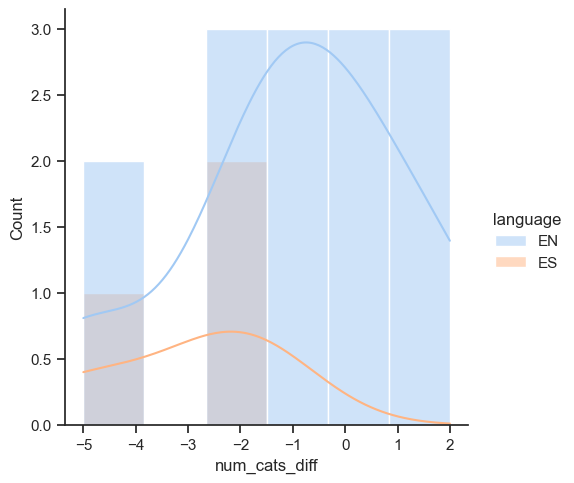

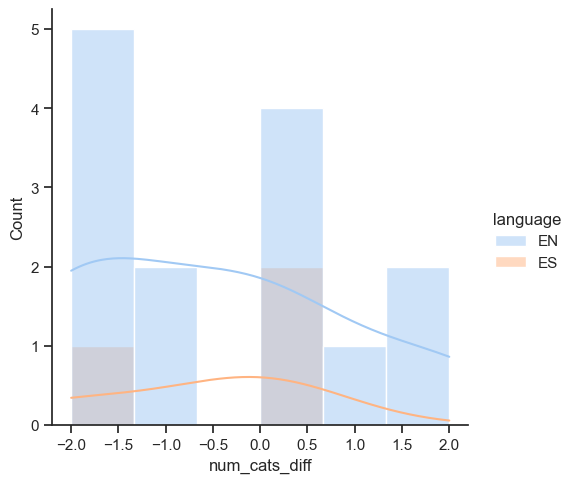

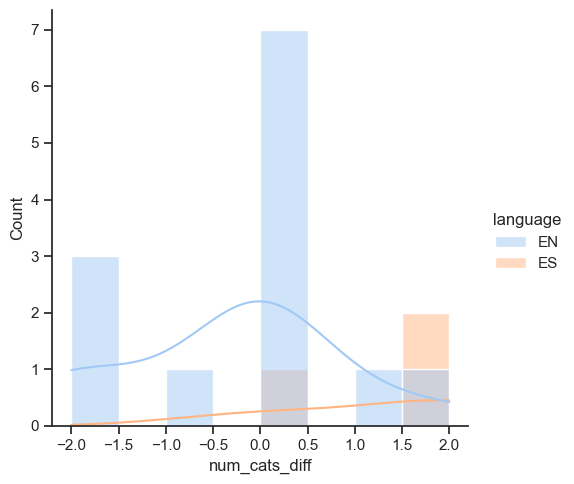

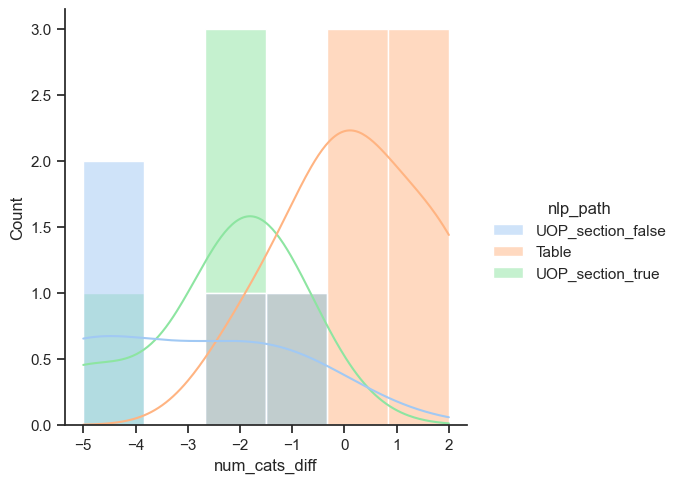

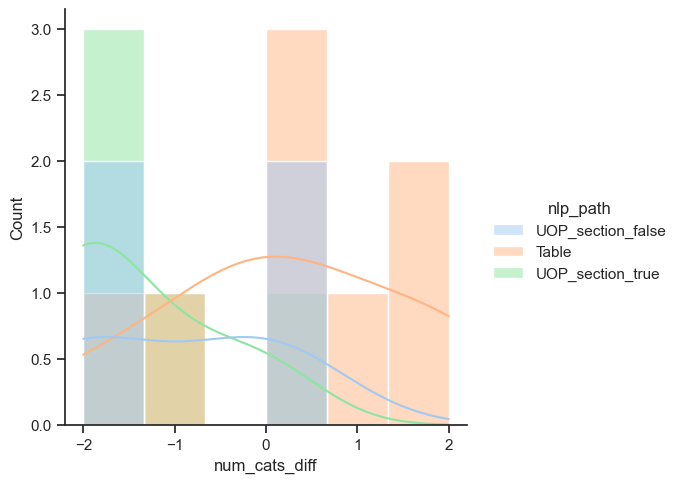

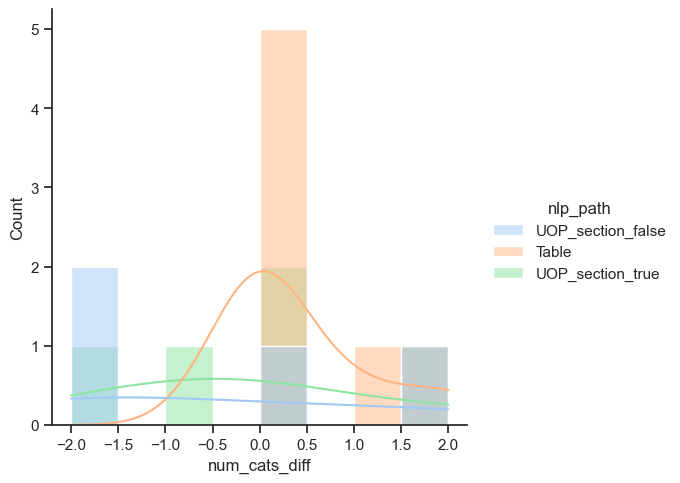

In [303]:
# breakdown of 

sns.displot(boxplot_df, x='num_cats_diff', hue= 'language', kde=True)
sns.displot(boxplot_df_v5, x='num_cats_diff', hue = 'language', kde=True)
sns.displot(boxplot_df_v6, x='num_cats_diff', hue = 'language', kde=True)
sns.displot(boxplot_df, x='num_cats_diff', hue= 'nlp_path', kde=True)
sns.displot(boxplot_df_v5, x='num_cats_diff', hue = 'nlp_path', kde=True)
sns.displot(boxplot_df_v6, x='num_cats_diff', hue = 'nlp_path', kde=True)


In [304]:
# stats - whole dataset and ES partial TPs - V5 sim TH = 0.80

#print(conf_mtrx_df_v5['num_cats_true'].describe())
#print(conf_mtrx_df_v5['num_cats_diff'].describe())
print(boxplot_df_v5['num_cats_true'].describe())
print(boxplot_df_v5['num_cats_diff'].describe())

count    17.000000
mean      4.823529
std       2.297697
min       2.000000
25%       3.000000
50%       5.000000
75%       6.000000
max       8.000000
Name: num_cats_true, dtype: float64
count    17.000000
mean     -0.529412
std       1.374666
min      -2.000000
25%      -2.000000
50%       0.000000
75%       0.000000
max       2.000000
Name: num_cats_diff, dtype: float64
